# MVLM-style 2D landmark training with rigid pre-alignment

This notebook trains the 2D landmark predictor on meshes and landmarks.

- multiple specimens are supported directly
- `N_SPECIMENS = None` uses **all available specimen pairs**
- a rigid landmark-based alignment step is applied before caching / rendering
- the checkpoint stores a **reference object** and the **reference landmarks** used for alignment
- evaluation of an unseen sample can optionally align that sample to the same reference using either the **reference object** of **the GroundTruth landmarks if available**

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import trimesh

from pathlib import Path
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from mvlm.utils import ObjVTKRenderer3D
from mvlm.prediction.predictor2d import Predictor2D

In [2]:
def load_landmarks(path):
    path = Path(path)

    if path.suffix.lower() == ".npy":
        L = np.load(path)
        return np.asarray(L, dtype=np.float64)

    if path.suffix.lower() == ".json":
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        if isinstance(data, dict) and "markups" in data:
            cps = data["markups"][0]["controlPoints"]
            return np.array([cp["position"] for cp in cps], dtype=np.float64)

        if isinstance(data, list):
            return np.array(data, dtype=np.float64)

        if isinstance(data, dict) and "landmarks" in data:
            return np.array(data["landmarks"], dtype=np.float64)

    raise ValueError(f"Unsupported landmark format: {path}")

In [3]:
def rot_x(deg):
    a = np.deg2rad(deg)
    return np.array([[1, 0, 0],
                     [0, np.cos(a), -np.sin(a)],
                     [0, np.sin(a),  np.cos(a)]], dtype=np.float64)


def rot_y(deg):
    a = np.deg2rad(deg)
    return np.array([[ np.cos(a), 0, np.sin(a)],
                     [0,          1, 0],
                     [-np.sin(a), 0, np.cos(a)]], dtype=np.float64)


def rot_z(deg):
    a = np.deg2rad(deg)
    return np.array([[np.cos(a), -np.sin(a), 0],
                     [np.sin(a),  np.cos(a), 0],
                     [0,          0,         1]], dtype=np.float64)


def load_vertices(obj_path: Path) -> np.ndarray:
    m = trimesh.load(obj_path, process=False)
    if isinstance(m, trimesh.Scene):
        m = trimesh.util.concatenate(tuple(m.geometry.values()))
    V = np.asarray(m.vertices, dtype=np.float32)
    if V.ndim != 2 or V.shape[1] != 3:
        raise ValueError(f"Bad vertices for {obj_path}: {V.shape}")
    return V


def load_mesh(obj_path: Path) -> trimesh.Trimesh:
    m = trimesh.load(obj_path, process=False)
    if isinstance(m, trimesh.Scene):
        m = trimesh.util.concatenate(tuple(m.geometry.values()))
    if not isinstance(m, trimesh.Trimesh):
        raise ValueError(f"Could not load mesh as Trimesh: {obj_path}")
    return m


def mesh_center_scale_from_vertices(V: np.ndarray, target_extent: float):
    mn, mx = V.min(axis=0), V.max(axis=0)
    c = 0.5 * (mn + mx)
    extent = mx - mn
    s = target_extent / float(extent.max() + 1e-12)
    return c.astype(np.float32), float(s)


def normalize_vertices(V: np.ndarray, c: np.ndarray, s: float) -> np.ndarray:
    return (V - c[None, :]) * s


def normalize_landmarks(L: np.ndarray, c: np.ndarray, s: float) -> np.ndarray:
    return (L - c[None, :]) * s


def normalize_mesh_to_temp(obj_path: Path, c, s, out_path: Path):
    m = load_mesh(obj_path)
    V = np.asarray(m.vertices, dtype=np.float32)
    m.vertices = (V - c[None, :]) * s
    out_path.parent.mkdir(parents=True, exist_ok=True)
    m.export(out_path)
    return out_path

In [4]:
def kabsch_rigid_transform(A, B):
    """
    Rigid transform mapping A -> B.
    A, B: (K,3)
    Returns R, t with x_aligned = (R @ x) + t
    """
    A = np.asarray(A, dtype=np.float64)
    B = np.asarray(B, dtype=np.float64)

    if A.shape != B.shape or A.ndim != 2 or A.shape[1] != 3:
        raise ValueError(f"Kabsch expects matching (K,3) arrays, got {A.shape} and {B.shape}")

    ca = A.mean(axis=0)
    cb = B.mean(axis=0)

    AA = A - ca
    BB = B - cb

    H = AA.T @ BB
    U, _, Vt = np.linalg.svd(H)

    R = Vt.T @ U.T
    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T

    t = cb - (R @ ca)
    return R, t


def apply_rigid(points, R, t):
    points = np.asarray(points, dtype=np.float64)
    return (R @ points.T).T + t


def align_mesh_and_landmarks_to_reference(obj_path, lm_path, ref_landmarks,
                                          out_obj_path, out_lm_path):
    """
    Align one specimen to reference landmarks and save:
      - aligned mesh as .obj
      - aligned landmarks as .npy
    """
    obj_path = Path(obj_path)
    lm_path = Path(lm_path)
    out_obj_path = Path(out_obj_path)
    out_lm_path = Path(out_lm_path)

    mesh = load_mesh(obj_path)
    V = np.asarray(mesh.vertices, dtype=np.float64)
    L = load_landmarks(lm_path).astype(np.float64)

    if L.shape != ref_landmarks.shape:
        raise ValueError(f"Landmark shape mismatch: {lm_path} has {L.shape}, ref has {ref_landmarks.shape}")

    R, t = kabsch_rigid_transform(L, ref_landmarks)

    V_aligned = apply_rigid(V, R, t)
    L_aligned = apply_rigid(L, R, t)

    mesh.vertices = V_aligned
    out_obj_path.parent.mkdir(parents=True, exist_ok=True)
    out_lm_path.parent.mkdir(parents=True, exist_ok=True)

    mesh.export(out_obj_path)
    np.save(out_lm_path, L_aligned.astype(np.float32))

    return out_obj_path, out_lm_path

In [5]:
def prepare_selected_pairs(pairs, n_specimens=None, start_index=0):
    if len(pairs) == 0:
        raise ValueError("No valid mesh / landmark pairs found.")

    if n_specimens is None:
        selected_pairs = pairs[start_index:]
    else:
        selected_pairs = pairs[start_index:start_index + int(n_specimens)]

    if len(selected_pairs) == 0:
        raise ValueError("Selection is empty. Check START_INDEX / N_SPECIMENS.")

    return selected_pairs


def align_selected_pairs(selected_pairs, aligned_dir):
    aligned_dir = Path(aligned_dir)
    aligned_dir.mkdir(parents=True, exist_ok=True)

    ref_obj_path, ref_lm_path = selected_pairs[0]
    ref_landmarks = load_landmarks(ref_lm_path).astype(np.float64)

    ref_landmarks_path = aligned_dir / "reference_landmarks.npy"
    np.save(ref_landmarks_path, ref_landmarks.astype(np.float32))

    aligned_pairs = []
    for obj_path, lm_path in selected_pairs:
        out_obj = aligned_dir / f"{Path(obj_path).stem}__aligned.obj"
        out_lm = aligned_dir / f"{Path(obj_path).stem}__aligned.npy"

        align_mesh_and_landmarks_to_reference(
            obj_path=obj_path,
            lm_path=lm_path,
            ref_landmarks=ref_landmarks,
            out_obj_path=out_obj,
            out_lm_path=out_lm,
        )
        aligned_pairs.append((out_obj, out_lm))

    return aligned_pairs, ref_landmarks, ref_landmarks_path, ref_obj_path.stem

In [6]:
def preprocess_depth(alpha_like):
    d = alpha_like.astype(np.float32)
    d = d - d.min()
    mx = float(d.max())
    if mx < 1e-8:
        return np.zeros_like(d, dtype=np.float32)
    return d / mx


def project_landmarks_mvlm(L_xyz, V_xyz, rx, ry, rz, sil, img_size):
    """
    MVLM-style 2D projection:
    1) rotate landmarks and vertices
    2) map rotated world x/y to the rendered silhouette bbox
    """
    R = (rot_y(ry) @ rot_x(rx)) @ rot_z(rz)

    Lr = (R @ L_xyz.T).T
    Vr = (R @ V_xyz.T).T

    xw_min, xw_max = Vr[:, 0].min(), Vr[:, 0].max()
    yw_min, yw_max = Vr[:, 1].min(), Vr[:, 1].max()

    ys, xs = np.where(sil > 1e-4)
    if len(xs) == 0 or len(ys) == 0:
        return np.full((L_xyz.shape[0], 2), np.nan, dtype=np.float32)

    xp_min, xp_max = xs.min(), xs.max()
    yp_min, yp_max = ys.min(), ys.max()

    x = Lr[:, 0]
    y = Lr[:, 1]

    x_px = xp_min + (x - xw_min) / max(xw_max - xw_min, 1e-8) * (xp_max - xp_min)
    y_px = yp_max - (y - yw_min) / max(yw_max - yw_min, 1e-8) * (yp_max - yp_min)

    pix_xy = np.stack([x_px, y_px], axis=1).astype(np.float32)
    pix_xy[:, 0] = np.clip(pix_xy[:, 0], 0, img_size - 1)
    pix_xy[:, 1] = np.clip(pix_xy[:, 1], 0, img_size - 1)
    return pix_xy


def gaussian_heatmaps_xy(pix_xy, H, W, sigma=3.0, truncate=3.0):
    K = pix_xy.shape[0]
    yy, xx = np.mgrid[0:H, 0:W].astype(np.float32)
    hms = np.zeros((K, H, W), dtype=np.float32)

    for k in range(K):
        x, y = pix_xy[k]
        if not np.isfinite(x) or not np.isfinite(y):
            continue
        d2 = (xx - x) ** 2 + (yy - y) ** 2
        hm = np.exp(-0.5 * d2 / (sigma ** 2))
        hm[d2 > (truncate * sigma) ** 2] = 0.0
        hms[k] = hm

    return hms


@torch.no_grad()
def heatmaps_to_yxconf(hm):
    K, H, W = hm.shape
    flat = hm.view(K, -1)
    vals, idx = flat.max(dim=1)
    ys = (idx // W).float()
    xs = (idx % W).float()
    return torch.stack([ys, xs, vals], dim=1)

In [7]:
class MVLMAlignedCachedDataset(Dataset):
    """
    Cached dataset with fixed rendered views.

    Expected input:
    - obj_paths / lm_paths already point to aligned files when alignment is enabled
    - each specimen is normalized once
    - each normalized mesh is rendered once
    - targets are generated with project_landmarks_mvlm()
    - views stay fixed across epochs
    """
    def __init__(self, obj_paths, lm_paths,
                 image_size=256, n_views=8,
                 sigma=3.0, target_extent=250.0,
                 norm_dir="data/_norm_meshes_aligned",
                 use_coord_channels=True,
                 debug_first=False):
        self.obj_paths = [Path(p) for p in obj_paths]
        self.lm_paths = [Path(p) for p in lm_paths]
        if len(self.obj_paths) != len(self.lm_paths):
            raise ValueError("obj_paths and lm_paths must have same length")

        self.H = self.W = int(image_size)
        self.n_views = int(n_views)
        self.sigma = float(sigma)
        self.target_extent = float(target_extent)
        self.use_coord_channels = bool(use_coord_channels)
        self.debug_first = bool(debug_first)

        self.renderer = ObjVTKRenderer3D(
            n_views=self.n_views,
            image_size=(self.H, self.W),
            offscreen=True,
        )

        yy, xx = np.mgrid[0:self.H, 0:self.W].astype(np.float32)
        self.xx = (xx / (self.W - 1)) * 2.0 - 1.0
        self.yy = (yy / (self.H - 1)) * 2.0 - 1.0

        self.samples = []
        self.sample_meta = []

        norm_dir = Path(norm_dir)
        norm_dir.mkdir(parents=True, exist_ok=True)

        for mi, (obj_path, lm_path) in enumerate(zip(self.obj_paths, self.lm_paths)):
            V = load_vertices(obj_path)
            c, s = mesh_center_scale_from_vertices(V, self.target_extent)
            Vn = normalize_vertices(V, c, s)

            L = load_landmarks(lm_path).astype(np.float32)
            if L.shape != (15, 3):
                raise ValueError(f"Expected landmarks with shape (15,3), got {L.shape} in {lm_path}")
            Ln = normalize_landmarks(L, c, s)

            norm_path = norm_dir / f"{obj_path.stem}__norm.obj"
            if not norm_path.exists():
                mesh = load_mesh(obj_path)
                mesh.vertices = normalize_vertices(np.asarray(mesh.vertices, dtype=np.float32), c, s)
                mesh.export(norm_path)

            image_stack, transform_stack, _ = self.renderer.multiview_render(norm_path)
            depth_stack = image_stack[..., 3].astype(np.float32)

            for vi in range(self.n_views):
                sil = preprocess_depth(depth_stack[vi])
                rx, ry, rz = transform_stack[vi, :3]

                pix_xy = project_landmarks_mvlm(
                    L_xyz=Ln,
                    V_xyz=Vn,
                    rx=rx,
                    ry=ry,
                    rz=rz,
                    sil=sil,
                    img_size=self.W,
                )

                heat = gaussian_heatmaps_xy(pix_xy, self.H, self.W, sigma=self.sigma)

                if self.use_coord_channels:
                    inp = np.stack([sil, self.xx, self.yy], axis=0)
                else:
                    inp = sil[None, ...]

                x = torch.from_numpy(inp).float()
                y = torch.from_numpy(heat).float()
                self.samples.append((x, y))
                self.sample_meta.append({
                    "specimen_index": mi,
                    "view_index": vi,
                    "obj_path": str(obj_path),
                    "lm_path": str(lm_path),
                })

                if self.debug_first and mi == 0 and vi == 0:
                    print("debug sample built")
                    print("input shape:", x.shape, "target shape:", y.shape)
                    print("GT x range:", float(np.nanmin(pix_xy[:, 0])), float(np.nanmax(pix_xy[:, 0])))
                    print("GT y range:", float(np.nanmin(pix_xy[:, 1])), float(np.nanmax(pix_xy[:, 1])))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

In [8]:
class SmallUNet(nn.Module):
    def __init__(self, out_ch=15, in_ch=3):
        super().__init__()

        def block(cin, cout):
            groups = 8 if cout % 8 == 0 else 4
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1),
                nn.GroupNorm(groups, cout),
                nn.ReLU(inplace=True),
                nn.Conv2d(cout, cout, 3, padding=1),
                nn.GroupNorm(groups, cout),
                nn.ReLU(inplace=True),
            )

        self.enc1 = block(in_ch, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = block(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = block(64, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = block(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = block(64, 32)

        self.head = nn.Sequential(
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, out_ch, 1),
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        d2 = self.up2(e3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.head(d1)

In [9]:
def landmark_identity_loss(logits, target_heatmaps):
    """
    At the GT position of landmark k, channel k should be higher than all other channels.
    """
    B, K, H, W = logits.shape
    gt_idx = target_heatmaps.view(B, K, -1).argmax(dim=-1)
    flat_logits = logits.view(B, K, -1)

    scores = torch.gather(
        flat_logits,
        2,
        gt_idx.unsqueeze(1).expand(-1, K, -1),
    )

    scores = scores.permute(0, 2, 1).reshape(B * K, K)
    targets = torch.arange(K, device=logits.device).repeat(B)
    return F.cross_entropy(scores, targets)


@torch.no_grad()
def eval_pixel_error(model, loader, device, logits=True, empty_thresh=1e-6):
    model.eval()

    all_dists = []
    all_conf = []
    empty_count = 0
    total_count = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        out = model(x)
        pred = torch.sigmoid(out) if logits else out

        B, K, H, W = pred.shape

        pred_flat = pred.view(B, K, -1)
        pred_vals, pred_idx = pred_flat.max(dim=2)
        pred_y = (pred_idx // W).float()
        pred_x = (pred_idx % W).float()

        gt_flat = y.view(B, K, -1)
        gt_vals, gt_idx = gt_flat.max(dim=2)
        gt_y = (gt_idx // W).float()
        gt_x = (gt_idx % W).float()

        empty = gt_vals < empty_thresh
        d = torch.sqrt((pred_x - gt_x) ** 2 + (pred_y - gt_y) ** 2)

        d_valid = d[~empty]
        conf_valid = pred_vals[~empty]

        if d_valid.numel() > 0:
            all_dists.append(d_valid.detach().cpu().numpy())
            all_conf.append(conf_valid.detach().cpu().numpy())

        empty_count += int(empty.sum().item())
        total_count += int(empty.numel())

    empty_rate = empty_count / max(1, total_count)

    if len(all_dists) == 0:
        return {
            "px_mean": float("nan"),
            "px_median": float("nan"),
            "px_90p": float("nan"),
            "conf_mean": float("nan"),
            "conf_median": float("nan"),
            "conf_10p": float("nan"),
            "conf_max": float("nan"),
            "empty_rate": float(empty_rate),
        }

    d = np.concatenate(all_dists, axis=0)
    c = np.concatenate(all_conf, axis=0)

    return {
        "px_mean": float(d.mean()),
        "px_median": float(np.median(d)),
        "px_90p": float(np.percentile(d, 90)),
        "conf_mean": float(c.mean()),
        "conf_median": float(np.median(c)),
        "conf_10p": float(np.percentile(c, 10)),
        "conf_max": float(c.max()),
        "empty_rate": float(empty_rate),
    }

In [10]:
@torch.no_grad()
def show_heatmap_debug(model, ds, idx=0, device="cpu",
                       logits=True, channels=(0, 1, 2, 3, 4),
                       save_path=None, show=True):
    model.eval()

    x, y = ds[idx]
    out = model(x.unsqueeze(0).to(device))[0]
    pred = torch.sigmoid(out) if logits else out

    x = x.cpu()
    y = y.cpu()
    pred = pred.cpu()

    img = x[0].numpy()

    n = len(channels)
    fig, axes = plt.subplots(n, 3, figsize=(10, 3 * n))
    if n == 1:
        axes = np.array([axes])

    for row, k in enumerate(channels):
        gt_hm = y[k].numpy()
        pr_hm = pred[k].numpy()

        gt_idx = np.argmax(gt_hm)
        pr_idx = np.argmax(pr_hm)
        H, W = gt_hm.shape
        gt_y, gt_x = divmod(gt_idx, W)
        pr_y, pr_x = divmod(pr_idx, W)

        axes[row, 0].imshow(img, origin="lower")
        axes[row, 0].scatter([gt_x], [gt_y], c="red", s=30, label="GT")
        axes[row, 0].scatter([pr_x], [pr_y], c="cyan", s=20, label="Pred")
        axes[row, 0].set_title(f"Landmark {k} on input")
        if row == 0:
            axes[row, 0].legend()

        axes[row, 1].imshow(gt_hm, origin="lower")
        axes[row, 1].set_title(f"GT heatmap {k}\nmax={gt_hm.max():.3f}")

        axes[row, 2].imshow(pr_hm, origin="lower")
        axes[row, 2].set_title(f"Pred heatmap {k}\nmax={pr_hm.max():.3f}")

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("saved:", save_path)

    if show:
        plt.show()
    else:
        plt.close()

In [11]:
@torch.no_grad()
def pixel_error_report_from_dataset(model, ds, idx=0, device="cpu", logits=True):
    model.eval()

    x, y = ds[idx]
    x_in = x.unsqueeze(0).to(device)
    y_in = y.unsqueeze(0).to(device)

    out = model(x_in)
    pred = torch.sigmoid(out) if logits else out

    K, H, W = y.shape

    pred_flat = pred[0].view(K, -1)
    gt_flat = y_in[0].view(K, -1)

    pred_vals, pred_idx = pred_flat.max(dim=1)
    _, gt_idx = gt_flat.max(dim=1)

    pred_y = (pred_idx // W).cpu().numpy().astype(float)
    pred_x = (pred_idx % W).cpu().numpy().astype(float)
    gt_y = (gt_idx // W).cpu().numpy().astype(float)
    gt_x = (gt_idx % W).cpu().numpy().astype(float)

    dy = pred_y - gt_y
    dx = pred_x - gt_x
    dist = np.sqrt(dy ** 2 + dx ** 2)

    df = pd.DataFrame({
        "landmark": np.arange(K),
        "pred_y": pred_y,
        "pred_x": pred_x,
        "gt_y": gt_y,
        "gt_x": gt_x,
        "dy": dy,
        "dx": dx,
        "px_dist": dist,
        "conf": pred_vals.cpu().numpy(),
    })

    print(f"sample {idx}: mean={df['px_dist'].mean():.2f}px, median={df['px_dist'].median():.2f}px")
    return df


@torch.no_grad()
def pixel_error_summary_over_dataset(model, ds, device="cpu", logits=True):
    model.eval()

    all_rows = []

    for idx in range(len(ds)):
        x, y = ds[idx]
        x_in = x.unsqueeze(0).to(device)
        y_in = y.unsqueeze(0).to(device)

        out = model(x_in)
        pred = torch.sigmoid(out) if logits else out

        K, H, W = y.shape

        pred_flat = pred[0].view(K, -1)
        gt_flat = y_in[0].view(K, -1)

        pred_vals, pred_idx = pred_flat.max(dim=1)
        _, gt_idx = gt_flat.max(dim=1)

        pred_y = (pred_idx // W).cpu().numpy().astype(float)
        pred_x = (pred_idx %  W).cpu().numpy().astype(float)
        gt_y = (gt_idx // W).cpu().numpy().astype(float)
        gt_x = (gt_idx %  W).cpu().numpy().astype(float)

        dy = pred_y - gt_y
        dx = pred_x - gt_x
        dist = np.sqrt(dy ** 2 + dx ** 2)

        meta = ds.sample_meta[idx] if hasattr(ds, "sample_meta") else {"specimen_index": None, "view_index": idx}

        for k in range(K):
            all_rows.append({
                "sample": idx,
                "specimen_index": meta.get("specimen_index"),
                "view_index": meta.get("view_index"),
                "landmark": k,
                "pred_y": pred_y[k],
                "pred_x": pred_x[k],
                "gt_y": gt_y[k],
                "gt_x": gt_x[k],
                "dy": dy[k],
                "dx": dx[k],
                "px_dist": dist[k],
                "conf": float(pred_vals[k].cpu().item()),
            })

    df_all = pd.DataFrame(all_rows)

    df_summary = (
        df_all.groupby("landmark", as_index=False)
        .agg(
            px_mean=("px_dist", "mean"),
            px_median=("px_dist", "median"),
            px_min=("px_dist", "min"),
            px_max=("px_dist", "max"),
            conf_mean=("conf", "mean"),
            valid_views=("px_dist", "count"),
        )
    )

    print(f"overall mean landmark error: {df_summary['px_mean'].mean():.2f}px")
    return df_summary, df_all

In [12]:
def train_model(obj_paths, lm_paths,
                image_size=256,
                n_views=8,
                batch_size=4,
                epochs=200,
                lr=1e-3,
                sigma=3.0,
                target_extent=250.0,
                save_path="bone_predictor2d.pt",
                seed=0,
                logits=True,
                use_coord_channels=True,
                identity_loss_weight=0.5,
                reference_landmarks=None,
                reference_name=None,
                reference_obj_path=None):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("device:", device)

    ds_train = MVLMAlignedCachedDataset(
        obj_paths=obj_paths,
        lm_paths=lm_paths,
        image_size=image_size,
        n_views=n_views,
        sigma=sigma,
        target_extent=target_extent,
        use_coord_channels=use_coord_channels,
    )
    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=0)

    in_ch = 3 if use_coord_channels else 1
    model = SmallUNet(out_ch=15, in_ch=in_ch).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss(reduction="none")

    debug_dir = Path("trainingLog")
    debug_dir.mkdir(parents=True, exist_ok=True)

    best_score = float("inf")
    best_state = None

    with open("trainingLog/training_log.txt", "w") as f:
        f.write("epoch,train_loss,train_px_mean,train_px_90p,train_conf_mean\n")

    for ep in range(1, epochs + 1):
        model.train()
        running = 0.0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            ### LOSS ###
            out = model(x)
            loss_map = criterion(out, y)
            w = 1.0 + 30.0 * y
            loss_bce = (loss_map * w).sum() / w.sum()
            loss_id = landmark_identity_loss(out, y)
            loss = loss_bce + identity_loss_weight * loss_id

            opt.zero_grad()
            loss.backward()
            opt.step()

            running += float(loss.item())

        train_loss = running / max(1, len(train_loader))
        train_stats = eval_pixel_error(model, train_loader, device=device, logits=logits)

        if ep in (1, 10, 25) or ep % 50 == 0 or ep == epochs:
            show_heatmap_debug(
                model,
                ds_train,
                idx=0,
                device=device,
                logits=logits,
                channels=(0, 1, 2, 3, 4),
                save_path=debug_dir / f"hm_epoch_{ep:03d}.png",
                show=False,
            )

        score = train_stats["px_mean"]
        if np.isfinite(score) and score < best_score:
            best_score = score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        log = (
            f"{ep},"
            f"{train_loss:.6f},"
            f"{train_stats['px_mean']:.2f},"
            f"{train_stats['px_90p']:.2f},"
            f"{train_stats['conf_mean']:.3f}"
        )
        print(log)

        with open("trainingLog/training_log.txt", "a") as f:
            f.write(log + "\n")

    state_to_save = best_state if best_state is not None else {
        k: v.detach().cpu().clone() for k, v in model.state_dict().items()
    }
    
    ckpt = {
        "state_dict": state_to_save,
        "image_size": image_size,
        "n_views": n_views,
        "sigma": sigma,
        "target_extent": target_extent,
        "use_coord_channels": use_coord_channels,
        "in_ch": in_ch,
        "identity_loss_weight": identity_loss_weight,
        "aligned_training": reference_landmarks is not None,
        "reference_name": reference_name,
        "ref_landmarks": None if reference_landmarks is None else torch.as_tensor(
            reference_landmarks, dtype=torch.float32
        ).cpu(),
        "ref_obj_path": None if reference_obj_path is None else str(reference_obj_path),
    }
    
    torch.save(ckpt, save_path)
    
    print("saved:", save_path, "| best_score:", best_score)
    
    if best_state is not None:
        model.load_state_dict(best_state)
    
    return model

## Select, align, and configure the training data

In [ ]:
mesh_dir = Path("data/meshesV2")
lm_dir = Path("data/landmarksV2")

all_obj_paths = sorted(mesh_dir.glob("*.obj"))
all_lm_paths = [lm_dir / f"{p.stem}_geomedian.mrk.json" for p in all_obj_paths]

pairs = [(obj, lm) for obj, lm in zip(all_obj_paths, all_lm_paths) if lm.exists()]
print("valid specimen pairs:", len(pairs))

# --------------------------------------------------
# Selection
# --------------------------------------------------
# Set N_SPECIMENS = None to use all available samples
# or set N_SPECIMENS to an integer for a smaller debug subset
N_SPECIMENS = None
START_INDEX = 0

# Whether to create aligned training files
ALIGN_TRAINING_SET = True
ALIGNED_DIR = Path("data/_aligned_training")

selected_pairs = prepare_selected_pairs(
    pairs,
    n_specimens=N_SPECIMENS,
    start_index=START_INDEX
)

original_obj_paths = [obj for obj, lm in selected_pairs]
original_lm_paths  = [lm  for obj, lm in selected_pairs]

print("selected specimens:")
for obj, lm in selected_pairs:
    print(" ", obj.name, "|", lm.name)

# Single source of truth for the reference specimen
reference_obj_path = selected_pairs[0][0]
reference_lm_path  = selected_pairs[0][1]
reference_name     = reference_obj_path.stem

print("\nreference specimen:")
print("Reference name:", reference_name)
print(" mesh:", reference_obj_path)
print(" lms :", reference_lm_path)

# Optional alignment of the training set
if ALIGN_TRAINING_SET:
    aligned_pairs, reference_landmarks, _, _ = align_selected_pairs(
        selected_pairs=selected_pairs,
        aligned_dir=ALIGNED_DIR,
    )

    obj_paths = [obj for obj, lm in aligned_pairs]
    lm_paths  = [lm  for obj, lm in aligned_pairs]

    print("\nUsing aligned training files:")
    for obj, lm in zip(obj_paths, lm_paths):
        print(" ", obj.name, "|", lm.name)
else:
    obj_paths = original_obj_paths
    lm_paths  = original_lm_paths
    reference_landmarks = None

print("\nFinal training set size:", len(obj_paths))

## Set Parameter

In [13]:
IMG_SIZE = 256
VIEWS = 8
SIGMA = 20.0
TAR_EXT = 250.0
USE_COORD_CHANNELS = True
BATCH_SIZE = 4
EPOCHS = 200
LR = 1e-3
IDENTITY_LOSS_WEIGHT = 0.5
SAVE_PATH = "bone_predictor2d.pt"

## Sanity check on the aligned cached training set

In [ ]:
ds_debug = MVLMAlignedCachedDataset(
    obj_paths=obj_paths,
    lm_paths=lm_paths,
    image_size=IMG_SIZE,
    n_views=VIEWS,
    sigma=SIGMA,
    target_extent=TAR_EXT,
    use_coord_channels=USE_COORD_CHANNELS,
    debug_first=True,
)

In [ ]:
x, y = ds_debug[0]
print("dataset length:", len(ds_debug))
print("x shape:", x.shape, "y shape:", y.shape)

depth = x[0].numpy()

hm = y
gt = heatmaps_to_yxconf(hm)

ys = gt[:,0].long()
xs = gt[:,1].long()
vals = depth[ys, xs]

print("depth at GT peaks:", vals)
print("min/mean/max:", vals.min(), vals.mean(), vals.max())

ys_fg, xs_fg = np.where(depth > 1e-4)

#print("Foreground bbox:")
#print("x:", xs_fg.min(), xs_fg.max(), "width:", xs_fg.max() - xs_fg.min())
#print("y:", ys_fg.min(), ys_fg.max(), "height:", ys_fg.max() - ys_fg.min())

#print("Landmark bbox:")
#print("x:", gt[:,1].min().item(), gt[:,1].max().item(), "width:", gt[:,1].max().item() - gt[:,1].min().item())
#print("y:", gt[:,0].min().item(), gt[:,0].max().item(), "height:", gt[:,0].max().item() - gt[:,0].min().item())

plt.figure(figsize=(6,6))
plt.imshow(depth, origin="lower")
plt.scatter(gt[:,1].numpy(), gt[:,0].numpy(), s=30, color=[1,0,0])  # x, y
#plt.savefig("TrainingHeatmapView0.pdf", bbox_inches='tight')
#plt.title("GT landmark peaks over depth (view 0)")
plt.show()

#print("GT conf min/mean/max:", float(gt[:,2].min()), float(gt[:,2].mean()), float(gt[:,2].max()))

## Train the aligned model

In [ ]:
model = train_model(
    obj_paths=obj_paths,
    lm_paths=lm_paths,
    image_size=IMG_SIZE,
    n_views=VIEWS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LR,
    sigma=SIGMA,
    target_extent=TAR_EXT,
    save_path=SAVE_PATH,
    use_coord_channels=USE_COORD_CHANNELS,
    identity_loss_weight=IDENTITY_LOSS_WEIGHT,
    reference_landmarks=load_landmarks(reference_lm_path).astype(np.float64),  #reference_landmarks,
    reference_name=Path(reference_obj_path).stem,  #reference_name=reference_name,
    reference_obj_path=reference_obj_path,
)

## Inspect heatmaps after training

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
show_heatmap_debug(
    model,
    ds_debug,
    idx=0,
    device=device,
    logits=True,
    channels=(0, 1, 2, 3, 4),
)

In [14]:
class BoneDepthPredictor2D(Predictor2D):
    def __init__(self, weights_path, device=None):
        super().__init__()
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        # always load checkpoint metadata on CPU
        ckpt = torch.load(weights_path, map_location="cpu", weights_only=False)

        self.in_ch = int(ckpt.get("in_ch", 1))
        self.use_coord_channels = bool(ckpt.get("use_coord_channels", self.in_ch == 3))

        self.model = SmallUNet(out_ch=15, in_ch=self.in_ch).to(self.device)
        self.model.load_state_dict(ckpt["state_dict"])
        self.model.eval()

        def to_numpy_cpu(x, dtype=np.float64):
            if x is None:
                return None
            if isinstance(x, torch.Tensor):
                x = x.detach().cpu().numpy()
            return np.asarray(x, dtype=dtype)

        # accept both old and new checkpoint key names
        ref_lm = ckpt.get("ref_landmarks", None)
        if ref_lm is None:
            ref_lm = ckpt.get("reference_landmarks", None)

        self.reference_landmarks = to_numpy_cpu(ref_lm, dtype=np.float64)

        self.image_size = int(ckpt.get("image_size", 256))
        self.n_views = int(ckpt.get("n_views", 8))
        self.target_extent = float(ckpt.get("target_extent", 250.0))

    def get_lm_count(self):
        return 15

    @torch.no_grad()
    def predict_landmarks_from_images(self, image_stack):
        depth_stack = image_stack[..., 3].astype(np.float32)
        V, H, W = depth_stack.shape

        yy, xx = np.mgrid[0:H, 0:W].astype(np.float32)
        xx = (xx / (W - 1)) * 2.0 - 1.0
        yy = (yy / (H - 1)) * 2.0 - 1.0

        lm2d = np.zeros((15, V, 3), dtype=np.float32)
        valid = np.zeros((15, V), dtype=bool)

        for vi in range(V):
            sil = preprocess_depth(depth_stack[vi])

            if self.use_coord_channels:
                inp = np.stack([sil, xx, yy], axis=0)
            else:
                inp = sil[None, ...]

            x = torch.from_numpy(inp[None, ...]).float().to(self.device)
            hm = torch.sigmoid(self.model(x))[0]

            yxconf = heatmaps_to_yxconf(hm).cpu().numpy()
            lm2d[:, vi, :] = yxconf
            valid[:, vi] = yxconf[:, 2] > 0.05

        return lm2d, valid

In [15]:
def prepare_eval_files(obj_path, gt_lm_path=None, predictor=None,
                       align_to_reference=False,
                       eval_align_dir="data/_aligned_eval"):
    obj_path = Path(obj_path)
    gt_lm_path = None if gt_lm_path is None else Path(gt_lm_path)

    if not align_to_reference:
        return obj_path, gt_lm_path

    if predictor is None or predictor.reference_landmarks is None:
        raise ValueError("Checkpoint does not contain reference landmarks for aligned evaluation.")

    if gt_lm_path is None:
        raise ValueError("Aligned evaluation requires gt_lm_path so the sample can be rigidly aligned to the reference.")

    eval_align_dir = Path(eval_align_dir)
    eval_align_dir.mkdir(parents=True, exist_ok=True)

    out_obj = eval_align_dir / f"{obj_path.stem}__aligned_eval.obj"
    out_lm = eval_align_dir / f"{obj_path.stem}__aligned_eval.npy"

    align_mesh_and_landmarks_to_reference(
        obj_path=obj_path,
        lm_path=gt_lm_path,
        ref_landmarks=predictor.reference_landmarks,
        out_obj_path=out_obj,
        out_lm_path=out_lm,
    )
    return out_obj, out_lm


def pixel_error_report_for_file(weights_path, obj_path, gt_lm_path,
                                image_size=256, n_views=8, target_extent=250.0,
                                view=None, return_arrays=False,
                                align_to_reference=False):
    predictor = BoneDepthPredictor2D(weights_path)

    eval_obj_path, eval_lm_path = prepare_eval_files(
        obj_path=obj_path,
        gt_lm_path=gt_lm_path,
        predictor=predictor,
        align_to_reference=align_to_reference,
    )

    V = load_vertices(eval_obj_path)
    c, s = mesh_center_scale_from_vertices(V, target_extent)
    Vn = normalize_vertices(V, c, s)

    tmp_norm = eval_obj_path.with_suffix("").with_name(eval_obj_path.stem + "__norm_eval.obj")
    norm_path = normalize_mesh_to_temp(eval_obj_path, c, s, tmp_norm)

    renderer = ObjVTKRenderer3D(
        n_views=n_views,
        image_size=(image_size, image_size),
        offscreen=True,
    )

    img_stack, transform_stack, _ = renderer.multiview_render(norm_path)
    pred2d, valid = predictor.predict_landmarks_from_images(img_stack)

    L = load_landmarks(eval_lm_path).astype(np.float32)
    Ln = normalize_landmarks(L, c, s)

    gt_yx_views = []
    for vi in range(transform_stack.shape[0]):
        rx, ry, rz = transform_stack[vi, :3]
        sil = preprocess_depth(img_stack[vi, :, :, 3])

        pix_xy = project_landmarks_mvlm(
            L_xyz=Ln,
            V_xyz=Vn,
            rx=rx,
            ry=ry,
            rz=rz,
            sil=sil,
            img_size=image_size,
        )

        gt_yx = np.stack([pix_xy[:, 1], pix_xy[:, 0]], axis=1)
        gt_yx_views.append(gt_yx)

    gt_yx_views = np.stack(gt_yx_views, axis=1)

    pred_yx = pred2d[..., :2]
    conf = pred2d[..., 2]

    dy = pred_yx[..., 0] - gt_yx_views[..., 0]
    dx = pred_yx[..., 1] - gt_yx_views[..., 1]
    dist = np.sqrt(dy ** 2 + dx ** 2)

    if view is not None:
        df = pd.DataFrame({
            "landmark": np.arange(dist.shape[0]),
            "pred_y": pred_yx[:, view, 0],
            "pred_x": pred_yx[:, view, 1],
            "gt_y": gt_yx_views[:, view, 0],
            "gt_x": gt_yx_views[:, view, 1],
            "dy": dy[:, view],
            "dx": dx[:, view],
            "px_dist": dist[:, view],
            "conf": conf[:, view],
            "valid": valid[:, view],
        })
        print(f"view {view}: mean={df['px_dist'].mean():.2f}px, median={df['px_dist'].median():.2f}px")
        return (df, dist, conf, gt_yx_views, pred2d) if return_arrays else df

    rows = []
    for k in range(dist.shape[0]):
        rows.append({
            "landmark": k,
            "px_mean": float(np.nanmean(dist[k])),
            "px_median": float(np.nanmedian(dist[k])),
            "px_min": float(np.nanmin(dist[k])),
            "px_max": float(np.nanmax(dist[k])),
            "conf_mean": float(np.nanmean(conf[k])),
            "valid_views": int(valid[k].sum()),
        })

    df = pd.DataFrame(rows)
    print(f"overall mean landmark error: {df['px_mean'].mean():.2f}px")
    return (df, dist, conf, gt_yx_views, pred2d) if return_arrays else df


def overlay_gt_and_pred_for_file(weights_path, obj_path, gt_lm_path, view=0,
                                 image_size=256, n_views=8, target_extent=250.0,
                                 align_to_reference=False, save_path=None):
    predictor = BoneDepthPredictor2D(weights_path)

    eval_obj_path, eval_lm_path = prepare_eval_files(
        obj_path=obj_path,
        gt_lm_path=gt_lm_path,
        predictor=predictor,
        align_to_reference=align_to_reference,
    )

    V = load_vertices(eval_obj_path)
    c, s = mesh_center_scale_from_vertices(V, target_extent)
    Vn = normalize_vertices(V, c, s)

    tmp_norm = eval_obj_path.with_suffix("").with_name(eval_obj_path.stem + "__norm_overlay.obj")
    norm_path = normalize_mesh_to_temp(eval_obj_path, c, s, tmp_norm)

    renderer = ObjVTKRenderer3D(
        n_views=n_views,
        image_size=(image_size, image_size),
        offscreen=True,
    )

    img_stack, transform_stack, _ = renderer.multiview_render(norm_path)
    pred2d, _ = predictor.predict_landmarks_from_images(img_stack)

    L = load_landmarks(eval_lm_path).astype(np.float32)
    Ln = normalize_landmarks(L, c, s)

    sil = preprocess_depth(img_stack[view, :, :, 3])
    rx, ry, rz = transform_stack[view, :3]
    pix_xy = project_landmarks_mvlm(
        L_xyz=Ln,
        V_xyz=Vn,
        rx=rx,
        ry=ry,
        rz=rz,
        sil=sil,
        img_size=image_size,
    )

    gt_y = pix_xy[:, 1]
    gt_x = pix_xy[:, 0]
    pr_y = pred2d[:, view, 0]
    pr_x = pred2d[:, view, 1]

    plt.figure(figsize=(6, 6))
    plt.imshow(sil, origin="lower")
    plt.scatter(gt_x, gt_y, s=30, c="red", label="GT")
    plt.scatter(pr_x, pr_y, s=20, c="cyan", label="Pred")
    #plt.title(f"GT vs predicted landmarks, view {view}")
    plt.legend()
    if save_path is not None:
        plt.savefig(save_path / f"2DPred-View{view}.png", bbox_inches='tight')
    plt.show()


## Evaluate on the aligned cached training set and on rendered files

The first two cells below measure performance on the **cached aligned training samples**.
That is the direct check of whether the training set itself is being fit.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

df_summary_train, df_all_train = pixel_error_summary_over_dataset(
    model, ds_debug, device=device, logits=True
)
#display(df_summary_train)

## Evaluate an unseen Specimen

reference_landmarks is None: False
reference_landmarks shape: (15, 3)
Render [0] - Prepare 0.000000 s
Render [1] - Setup time:  0.467729 s
Render [2] - Render 0.692673 s
overall mean landmark error: 8.01px


,landmark,px_mean,px_median,px_min,px_max,conf_mean,valid_views
0,0,8.739392,9.497703,3.568685,13.595115,0.997414,8
1,1,4.685113,4.335314,1.792421,8.274236,0.985178,8
2,2,4.145284,4.130221,1.843555,6.358867,0.999534,8
3,3,2.637670,2.608689,0.866898,4.467491,0.999731,8
4,4,4.454140,3.148301,0.899203,9.214307,0.999866,8
5,5,4.184477,3.722302,1.985390,7.874670,0.999238,8
6,6,4.167509,3.438501,1.143412,8.718510,0.988462,8
7,7,11.150307,12.747549,3.746333,16.928329,0.995829,8
8,8,21.914574,22.939901,12.306095,27.020559,0.996436,8
9,9,5.488499,4.659791,2.424825,10.730088,0.997971,8


Render [0] - Prepare 0.000000 s
Render [1] - Setup time:  0.413216 s
Render [2] - Render 0.560813 s


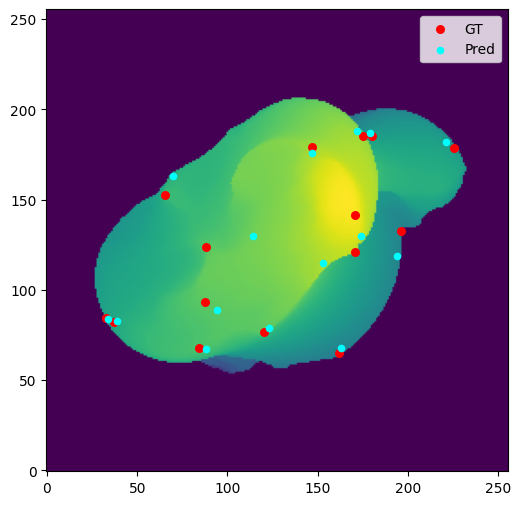

In [16]:
#UNSEEN_OBJ = Path("data/UNSEEN/THE-MA-60.obj")  #SAPM-MA-03214
#UNSEEN_GT = Path("data/UNSEEN/THE-MA-60.mrk.json")
#OUTPUT_PATH = Path("data/UNSEEN/output")

UNSEEN_OBJ = Path("data/UNSEEN-GAZELLE/SAPM-MA-02067.obj")
UNSEEN_GT = Path("data/UNSEEN-GAZELLE/SAPM-MA-02067.mrk.json")
OUTPUT_PATH = Path("data/UNSEEN-GAZELLE/output")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

pred = BoneDepthPredictor2D(SAVE_PATH)
print("reference_landmarks is None:", pred.reference_landmarks is None)
if pred.reference_landmarks is not None:
    print("reference_landmarks shape:", pred.reference_landmarks.shape)

if UNSEEN_OBJ is not None and UNSEEN_GT is not None:
    df_unseen = pixel_error_report_for_file(
        weights_path=SAVE_PATH,
        obj_path=UNSEEN_OBJ,
        gt_lm_path=UNSEEN_GT,
        image_size=IMG_SIZE,
        n_views=VIEWS,
        target_extent=TAR_EXT,
        view=None,
        align_to_reference=True,
    )
    display(df_unseen)

    overlay_gt_and_pred_for_file(
        weights_path=SAVE_PATH,
        obj_path=UNSEEN_OBJ,
        gt_lm_path=UNSEEN_GT,
        image_size=IMG_SIZE,
        n_views=VIEWS,
        target_extent=TAR_EXT,
        view=0,
        align_to_reference=True,
        save_path=OUTPUT_PATH,
    )
else:
    print("Set UNSEEN_OBJ and UNSEEN_GT to evaluate a new sample.")

## Reconstruct 3D landmarks from the aligned 2D predictions

This section adds the MVLM-style 2D-to-3D reconstruction back into the aligned workflow.

What it does:
- loads the saved aligned 2D checkpoint
- builds a `Pipeline`
- aligns an input mesh to the saved training reference (when GT landmarks are available)
- normalizes, renders, predicts 2D landmarks, back-projects the predicted pixels into 3D rays
- reconstructs the 3D landmark positions in aligned-normalized space
- maps the final prediction back to the **original mesh coordinates**

In [17]:
import copy
import numpy as np
import open3d as o3d

from types import SimpleNamespace
import types
from mvlm.utils.estimator3d import Estimator3D

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [18]:
def make_custom_pipeline():
    pipe = SimpleNamespace()
    pipe.estimator_3d = Estimator3D()
    pipe.predictor_2d = None
    pipe.renderer = None
    pipe.target_extent = None
    pipe.image_size = None
    pipe.n_views = None
    pipe.ref_landmarks = None
    return pipe


def denormalize_landmarks(Ln: np.ndarray, c: np.ndarray, s: float) -> np.ndarray:
    Ln = np.asarray(Ln, dtype=np.float64)
    c = np.asarray(c, dtype=np.float64)
    return (Ln / float(s)) + c[None, :]


def invert_rigid(points, R, t):
    """
    Inverse of x_aligned = R @ x + t
    Returns original-space points.
    """
    points = np.asarray(points, dtype=np.float64)
    R = np.asarray(R, dtype=np.float64)
    t = np.asarray(t, dtype=np.float64)
    return (R.T @ (points - t).T).T

In [19]:
def rigid_transform_from_o3d(T):
    R = T[:3, :3].astype(np.float64)
    t = T[:3, 3].astype(np.float64)
    return R, t

def apply_transform_points(points, T):
    points = np.asarray(points, dtype=np.float64)
    R = T[:3, :3]
    t = T[:3, 3]
    return (R @ points.T).T + t

def pca_frame(points):
    P = np.asarray(points, dtype=np.float64)
    c = P.mean(axis=0)
    X = P - c
    C = np.cov(X.T)
    evals, evecs = np.linalg.eigh(C)
    order = np.argsort(evals)[::-1]
    evecs = evecs[:, order]
    if np.linalg.det(evecs) < 0:
        evecs[:, -1] *= -1
    return c, evecs

def make_pca_init(source_pts, target_pts, flip=(1,1,1)):
    cs, Rs = pca_frame(source_pts)
    ct, Rt = pca_frame(target_pts)

    F = np.diag(flip)
    R = Rt @ F @ Rs.T
    if np.linalg.det(R) < 0:
        return None

    T = np.eye(4, dtype=np.float64)
    T[:3, :3] = R
    T[:3, 3] = ct - R @ cs
    return T

def align_mesh_to_reference_icp(unseen_obj_path, ref_obj_path,
                                voxel_size=2.0, max_corr=8.0):
    src_mesh = o3d.io.read_triangle_mesh(str(unseen_obj_path), enable_post_processing=True)
    tgt_mesh = o3d.io.read_triangle_mesh(str(ref_obj_path), enable_post_processing=True)

    src = src_mesh.sample_points_uniformly(20000)
    tgt = tgt_mesh.sample_points_uniformly(20000)

    src_pts = np.asarray(src.points)
    tgt_pts = np.asarray(tgt.points)

    # downsample for registration
    src_ds = src.voxel_down_sample(voxel_size)
    tgt_ds = tgt.voxel_down_sample(voxel_size)

    best = None
    best_fit = -np.inf

    # try PCA sign variants
    for flip in [(1,1,1), (1,-1,-1), (-1,1,-1), (-1,-1,1)]:
        T0 = make_pca_init(np.asarray(src_ds.points), np.asarray(tgt_ds.points), flip=flip)
        if T0 is None:
            continue

        reg = o3d.pipelines.registration.registration_icp(
            src_ds, tgt_ds,
            max_correspondence_distance=max_corr,
            init=T0,
            estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPoint()
        )

        if reg.fitness > best_fit:
            best_fit = reg.fitness
            best = reg.transformation.copy()

    if best is None:
        raise RuntimeError("ICP alignment failed.")

    return best

In [20]:
def estimate_landmark_lines_mvlm_bbox(self, image_stack, landmarks_stack, transform_stack):
    """
    Inverse of project_landmarks_mvlm().
    Assumes R maps world -> rotated/view coordinates, because forward projection uses:
        Lr = R @ L

    Therefore, to build world-space rays from recovered (x_view, y_view),
    we must use R.T (view -> world).
    """
    V_xyz = getattr(self, "current_vertices", None)
    if V_xyz is None:
        raise ValueError("estimator_3d.current_vertices is missing.")

    n_landmarks = landmarks_stack.shape[0]
    n_views = landmarks_stack.shape[1]

    line_starts = np.empty((n_landmarks, n_views, 3), dtype=np.float64)
    line_finish = np.empty((n_landmarks, n_views, 3), dtype=np.float64)

    z0 = 500.0
    z1 = -500.0

    for idx in range(n_views):
        sil = preprocess_depth(image_stack[idx, :, :, 3].astype(np.float32))
        ys, xs = np.where(sil > 1e-4)

        if len(xs) == 0 or len(ys) == 0:
            line_starts[:, idx, :] = np.nan
            line_finish[:, idx, :] = np.nan
            continue

        xp_min, xp_max = xs.min(), xs.max()
        yp_min, yp_max = ys.min(), ys.max()

        rx, ry, rz = transform_stack[idx, :3]

        # same convention as forward projection
        R = (rot_y(ry) @ rot_x(rx)) @ rot_z(rz)   # world -> view
        R_inv = R.T                                # view  -> world

        Vr = (R @ V_xyz.T).T
        xw_min, xw_max = Vr[:, 0].min(), Vr[:, 0].max()
        yw_min, yw_max = Vr[:, 1].min(), Vr[:, 1].max()

        for lm_no in range(n_landmarks):
            y = float(landmarks_stack[lm_no, idx, 0])
            x = float(landmarks_stack[lm_no, idx, 1])

            # recover view-plane coordinates from pixel coordinates
            xv = xw_min + ((x - xp_min) / max(xp_max - xp_min, 1e-8)) * (xw_max - xw_min)
            yv = yw_min + ((yp_max - y) / max(yp_max - yp_min, 1e-8)) * (yw_max - yw_min)

            # choose two points on the orthographic ray in VIEW coordinates
            p0_view = np.array([xv, yv, z0], dtype=np.float64)
            p1_view = np.array([xv, yv, z1], dtype=np.float64)

            # convert back to WORLD coordinates using the inverse rotation
            p0_world = R_inv @ p0_view
            p1_world = R_inv @ p1_view

            line_starts[lm_no, idx] = p0_world
            line_finish[lm_no, idx] = p1_world

    return line_starts, line_finish

In [21]:
def closest_point_to_lines(points, directions, weights=None, eps=1e-12):
    """
    Solve for the 3D point x that minimizes summed squared distances to lines.

    Each line is:
        x_i(t) = p_i + t * d_i

    points:     (N,3)
    directions: (N,3)
    weights:    (N,) or None
    """
    points = np.asarray(points, dtype=np.float64)
    directions = np.asarray(directions, dtype=np.float64)

    # normalize directions
    norms = np.linalg.norm(directions, axis=1, keepdims=True)
    directions = directions / np.clip(norms, eps, None)

    if weights is None:
        weights = np.ones(len(points), dtype=np.float64)
    else:
        weights = np.asarray(weights, dtype=np.float64)

    A = np.zeros((3, 3), dtype=np.float64)
    b = np.zeros(3, dtype=np.float64)

    I = np.eye(3, dtype=np.float64)

    for p, d, w in zip(points, directions, weights):
        P = I - np.outer(d, d)
        A += w * P
        b += w * (P @ p)

    try:
        x = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        x = np.linalg.lstsq(A, b, rcond=None)[0]

    return x

In [22]:
def reconstruct_landmarks_from_lines_ls(landmark_stack, lines_s, lines_e, min_views=2):
    """
    landmark_stack: (K,V,3) with (y,x,conf)
    lines_s:        (K,V,3)
    lines_e:        (K,V,3)

    Returns:
        pred_landmarks: (K,3)
        residuals:      (K,)
    """
    K, V, _ = landmark_stack.shape
    pred = np.full((K, 3), np.nan, dtype=np.float64)
    residuals = np.full(K, np.nan, dtype=np.float64)

    for k in range(K):
        conf = landmark_stack[k, :, 2]
        valid = (
            np.isfinite(lines_s[k]).all(axis=1) &
            np.isfinite(lines_e[k]).all(axis=1) &
            np.isfinite(conf) &
            (conf > 0.0)
        )

        if valid.sum() < min_views:
            continue

        p = lines_s[k, valid]
        d = lines_e[k, valid] - lines_s[k, valid]
        w = conf[valid]

        x = closest_point_to_lines(p, d, weights=w)
        pred[k] = x

        # residual = mean point-to-line distance
        d = d / np.clip(np.linalg.norm(d, axis=1, keepdims=True), 1e-12, None)
        diff = x[None, :] - p
        orth = diff - (diff * d).sum(axis=1, keepdims=True) * d
        residuals[k] = np.mean(np.linalg.norm(orth, axis=1))

    return pred, residuals

In [23]:
def landmark_error_report_3d(pred_landmarks, gt_lm_path):
    """
    Compute per-landmark 3D Euclidean distances in the original mesh coordinate system.
    """
    gt = load_landmarks(gt_lm_path).astype(np.float64)
    pred = np.asarray(pred_landmarks, dtype=np.float64)

    if pred.shape != gt.shape:
        raise ValueError(f"Shape mismatch: pred {pred.shape} vs gt {gt.shape}")

    d = np.linalg.norm(pred - gt, axis=1)
    df = pd.DataFrame({
        "landmark": np.arange(len(d)),
        "pred_x": pred[:, 0],
        "pred_y": pred[:, 1],
        "pred_z": pred[:, 2],
        "gt_x": gt[:, 0],
        "gt_y": gt[:, 1],
        "gt_z": gt[:, 2],
        "dist_3d": d,
    })
    print(f"3D mean error: {df['dist_3d'].mean():.3f}")
    return df

In [24]:
def predict_one_file_aligned(self, file_name, gt_lm_path=None, debug=False, debug_lm=0):
    """
    Predict 3D landmarks for one mesh and return them in ORIGINAL mesh coordinates.

    Parameters
    ----------
    file_name : path-like
        Path to the original mesh.
    gt_lm_path : path-like or None
        If provided, the mesh is rigidly aligned to the saved training reference
        using GT landmarks. This is useful for debugging / benchmarking on unseen samples.
        If None, the mesh is assumed to already be in the same canonical orientation
        as the training data.
    debug : bool
        Print a few intermediate values.
    """
    file_name = Path(file_name)
    gt_lm_path = None if gt_lm_path is None else Path(gt_lm_path)

    mesh = load_mesh(file_name)
    V_raw = np.asarray(mesh.vertices, dtype=np.float64)

    R_align = np.eye(3, dtype=np.float64)
    t_align = np.zeros(3, dtype=np.float64)

    # Align unseen sample to the saved training reference
    if gt_lm_path is not None:
        if not hasattr(self, "ref_landmarks") or self.ref_landmarks is None:
            raise ValueError("Pipeline has no ref_landmarks saved in the checkpoint.")
        L_raw = load_landmarks(gt_lm_path).astype(np.float64)
        R_align, t_align = kabsch_rigid_transform(L_raw, self.ref_landmarks)
        V_aligned = apply_rigid(V_raw, R_align, t_align)
    else:
        if not hasattr(self, "ref_obj_path") or self.ref_obj_path is None:
            raise ValueError("Pipeline has no reference mesh for non-GT alignment.")
        T_align = align_mesh_to_reference_icp(
            unseen_obj_path=file_name,
            ref_obj_path=self.ref_obj_path,
            voxel_size=2.0,
            max_corr=8.0
            )
        R_align = T_align[:3, :3]
        t_align = T_align[:3, 3]
        V_aligned = apply_transform_points(V_raw, T_align)
    
    tmp_aligned = file_name.with_name(file_name.stem + "__aligned_tmp.obj")
    mesh.vertices = V_aligned
    mesh.export(tmp_aligned)

    # Normalize exactly like training
    c, s = mesh_center_scale_from_vertices(V_aligned, self.target_extent)
    Vn = normalize_vertices(V_aligned, c, s)

    tmp_norm = file_name.with_name(file_name.stem + "__aligned_norm_tmp.obj")
    mesh.vertices = Vn
    mesh.export(tmp_norm)

    # Render and predict 2D landmarks
    img_stack, transform_stack, _ = self.renderer.multiview_render(tmp_norm)

    landmark_stack, valid = self.predictor_2d.predict_landmarks_from_images(img_stack)

    conf = landmark_stack[..., 2]
    conf_max = conf.max(axis=1, keepdims=True)
    landmark_stack[..., 2] = np.clip(conf / (conf_max + 1e-8), 0.0, 1.0)

    if debug:
        yx = landmark_stack[..., :2]
        print("y min/max:", float(yx[..., 0].min()), float(yx[..., 0].max()))
        print("x min/max:", float(yx[..., 1].min()), float(yx[..., 1].max()))
        print("views per lm (>0.05):", (landmark_stack[..., 2] > 0.05).sum(axis=1))

    self.estimator_3d.current_vertices = Vn.astype(np.float64)
    
    lines_s, lines_e = self.estimator_3d.estimate_landmark_lines(
        img_stack, landmark_stack, transform_stack
    )
    
    pred_landmarks_norm_aligned, err = reconstruct_landmarks_from_lines_ls(
        landmark_stack, lines_s, lines_e, min_views=2
    )
    pred_landmarks_norm_aligned = np.asarray(pred_landmarks_norm_aligned).reshape(-1, 3)

    # 5) Undo normalization, then undo alignment
    pred_landmarks_aligned = denormalize_landmarks(
        pred_landmarks_norm_aligned, c.astype(np.float64), float(s)
    )
    pred_landmarks_raw = invert_rigid(pred_landmarks_aligned, R_align, t_align)

    if debug:
        print("pred bbox aligned:",
              pred_landmarks_aligned.min(axis=0),
              pred_landmarks_aligned.max(axis=0))
        print("pred bbox raw:",
              pred_landmarks_raw.min(axis=0),
              pred_landmarks_raw.max(axis=0))
        if np.size(err) > 0:
            print("estimator error summary:", np.nanmin(err), np.nanmean(err), np.nanmax(err))

    return pred_landmarks_raw

In [25]:
def build_aligned_3d_pipeline(weights_path, image_size=256, n_views=8, target_extent=250.0):
    pipe = make_custom_pipeline()

    pipe.predictor_2d = BoneDepthPredictor2D(weights_path)
    pipe.renderer = ObjVTKRenderer3D(
        n_views=n_views,
        image_size=(image_size, image_size),
        offscreen=True
    )

    ckpt = torch.load(weights_path, map_location="cpu", weights_only=False)

    pipe.target_extent = float(ckpt.get("target_extent", target_extent))
    pipe.image_size = int(ckpt.get("image_size", image_size))
    pipe.n_views = int(ckpt.get("n_views", n_views))

    pipe.ref_landmarks = None if ckpt.get("ref_landmarks", None) is None else (
        ckpt["ref_landmarks"].detach().cpu().numpy().astype(np.float64)
        if isinstance(ckpt["ref_landmarks"], torch.Tensor)
        else np.asarray(ckpt["ref_landmarks"], dtype=np.float64)
    )

    ref_obj_path = ckpt.get("ref_obj_path", None)
    pipe.ref_obj_path = None if ref_obj_path is None else Path(ref_obj_path)

    pipe.estimator_3d.estimate_landmark_lines = types.MethodType(
        estimate_landmark_lines_mvlm_bbox, pipe.estimator_3d
    )
    pipe.predict_one_file = types.MethodType(predict_one_file_aligned, pipe)

    return pipe

In [26]:
# --------------------------------------------------
# Predict 3D landmarks for a new UNSEEN sample
# --------------------------------------------------

#UNSEEN_OBJ_3D = Path("data/UNSEEN/THE-MA-60.obj")
#UNSEEN_GT_3D = Path("data/UNSEEN/THE-MA-60.mrk.json")
#UNSEEN_GT_3D = None

UNSEEN_OBJ_3D = Path("data/UNSEEN-GAZELLE/SAPM-MA-02067.obj")
UNSEEN_GT_3D = Path("data/UNSEEN-GAZELLE/SAPM-MA-02067.mrk.json")

pathToOut3D = Path("data/UNSEEN/output")
pathToOut3D.mkdir(parents=True, exist_ok=True)

if UNSEEN_OBJ_3D is not None:
    pipe3d = build_aligned_3d_pipeline(SAVE_PATH)

    pred_unseen_3d = pipe3d.predict_one_file(
        UNSEEN_OBJ_3D,
        gt_lm_path=UNSEEN_GT_3D,
        debug=True,
    )

    out_path_unseen_3d = pathToOut3D / f"{Path(UNSEEN_OBJ_3D).stem}_predicted.txt"
    np.savetxt(out_path_unseen_3d, pred_unseen_3d, delimiter=",")
    print("Saved:", out_path_unseen_3d)
    print(pred_unseen_3d[:3])

    if UNSEEN_GT_3D is not None:
        df_unseen_3d = landmark_error_report_3d(pred_unseen_3d, UNSEEN_GT_3D)
        display(df_unseen_3d)
else:
    print("Set UNSEEN_OBJ_3D (and optionally UNSEEN_GT_3D) to run 3D prediction.")

Render [0] - Prepare 0.000000 s
Render [1] - Setup time:  0.371423 s
Render [2] - Render 0.615854 s
y min/max: 44.0 196.0
x min/max: 27.0 235.0
views per lm (>0.05): [8 8 8 8 8 8 8 8 8 8 8 8 8 8 8]
pred bbox aligned: [-8.61597986 -6.67368007 23.26493969] [13.20332963  8.56915701 46.90952316]
pred bbox raw: [ -6.2388529  -12.75300395  20.86547304] [ 6.99962589  9.47898323 45.03911412]
estimator error summary: 1.4329709184279522 2.9724413895780333 4.731292633974221
Saved: data\UNSEEN\output\SAPM-MA-02067_predicted.txt
[[ -3.78680822   0.61046142  45.03911412]
 [  3.96713459 -11.02664247  27.22733565]
 [ -4.28577474   8.19415898  38.93573637]]
3D mean error: 1.193


,landmark,pred_x,pred_y,pred_z,gt_x,gt_y,gt_z,dist_3d
0,0,-3.786808,0.610461,45.039114,-2.953389,1.478844,45.531242,1.300333
1,1,3.967135,-11.026642,27.227336,3.683409,-11.531178,26.907246,0.661449
2,2,-4.285775,8.194159,38.935736,-3.899311,8.235941,39.361973,0.576869
3,3,2.500040,-2.126056,21.385980,2.453918,-2.219313,21.182831,0.228240
4,4,2.741612,0.030242,20.865473,2.404220,-0.568162,20.610744,0.732672
5,5,0.973558,-12.753004,28.324025,0.566645,-12.562384,28.136122,0.487054
6,6,-6.238853,-4.532768,40.447901,-6.122649,-4.169219,40.892845,0.586213
7,7,2.051500,-3.587892,40.221446,0.901846,-2.356536,41.066704,1.884782
8,8,-2.276551,-8.482974,31.689729,-2.618483,-10.552440,28.939915,3.458480
9,9,6.999626,-5.086234,35.522173,7.486406,-4.598537,35.282196,0.729652
